## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pickle
import os

from nds_toolbox.sim.bursts.simulator import simulate_bursty_signal
from nds_toolbox.preprocessing.features import (compute_tde,trim_data)
from nds_toolbox.preprocessing.features import choose_embedding_dim
from nds_toolbox.utils.helper import compare_decoding_performance

/home/gerrit/Bachelor/MC-TDE-DP-GMM/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Pyplot Parameters

In [40]:
FIG_WIDTH = 7.5
MY_FONT_SIZE = 9

plt.rcParams.update({

    # --- Fonts ---
    "font.size": MY_FONT_SIZE,

    # --- Legend ---
    "legend.fontsize": MY_FONT_SIZE,
    "legend.frameon": False,

    # --- Titles ---
    "figure.titlesize": MY_FONT_SIZE,
    "axes.titleweight": "normal",
    "axes.titlesize": MY_FONT_SIZE,

    # --- Axes ---
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.unicode_minus": True,
    "axes.labelsize": MY_FONT_SIZE,

    # --- Lines & markers ---
    "lines.linewidth": 1.0,
    "lines.markersize": 0.7,

    # --- Ticks ---
    "xtick.labelsize": MY_FONT_SIZE,
    "ytick.labelsize": MY_FONT_SIZE,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.bottom": True,
    "ytick.left": True,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "axes.linewidth": 0.7,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,

    # Grid
    "axes.grid": False,
    "grid.linestyle": ":",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.5,

    # --- Layout ---
    "figure.autolayout": True,

    # --- DPI ---
    "savefig.dpi": 900,
    "figure.dpi": 300,
})


In [52]:
sim_cond = "emb_test_fs250_same_onset"
signal_dir = "../data/simulations"
performance_dir = "../data/performance"
result_dir = "../data/results"

sim_data = np.load(f'{signal_dir}/{sim_cond}_data.npz', allow_pickle=True)
signal_samples = sim_data['signal_samples']
states_samples = sim_data['states_samples']
bursts_samples = sim_data['bursts_samples']

sim_results = np.load(f'{result_dir}/{sim_cond}_results.npz', allow_pickle=True)
results = sim_results['results']




## Calculate MCCs

In [83]:
from nds_toolbox.utils.helper import match_states
from nds_toolbox.analysis.utils import imputing_mode
from nds_toolbox.sim.bursts.simulator import simulate_bursty_signal
from nds_toolbox.preprocessing.features import (compute_tde,trim_data)
from nds_toolbox.preprocessing.features import choose_embedding_dim
from nds_toolbox.utils.helper import compare_decoding_performance
from nds_toolbox.models.dpgmm_numpyro import fit_DPGMM, truncate, get_states
from sklearn.metrics import matthews_corrcoef
import jax.numpy as jnp
import math

num_emb = 21
num_embs = [3,5,7,9,11,13,15,17,19,21,23,25,27,29,31,33,35] 
use_different_emb = True

mccs = np.empty_like(results)

freqs = [10, 20, 30, 40, 50]

for s_id, sample in enumerate(results):
    for cond1_id, cond1 in enumerate(sample):
        for cond2_id, cond2 in enumerate(cond1):
            for snr_id, snr in enumerate(cond2):
                for res_id, res in enumerate(snr):
                    if use_different_emb:
                        num_emb = num_embs[snr_id]
                    # extract parameters
                    est_params = res["est_params"]
                    alpha = est_params["alpha"]
                    weights = est_params["weights"]
                    means = est_params["means"]
                    covs = est_params["covs"]

                    #get true states
                    states = states_samples[s_id, cond1_id, cond2_id, snr_id, 0]                 
                    states2 = states_samples[s_id, cond1_id, cond2_id, snr_id, res_id+1]
                    print(states.shape)
                    combined_states = np.empty_like(states)
                    state_dict = {'00': 0}
                    state_num = 1
                    for i, (s1, s2) in enumerate(zip(states, states2)):
                        s =  str(s1) + str(s2)
                        if s not in state_dict:
                            state_dict[s] = state_num
                            state_num += 1
                        combined_states[i] = state_dict[s]


                 
                    trimmed_states = trim_data(combined_states, num_emb, verbose = False)




                    #generate tde
                    signal = signal_samples[s_id, cond1_id, cond2_id, snr_id, 0]
                    signal2 = signal_samples[s_id, cond1_id, cond2_id, snr_id, res_id+1]

                    signal = (signal - np.mean(signal))/ np.std(signal)
                    signal2 = (signal2 - np.mean(signal2))/ np.std(signal2)


                    tde_signal = compute_tde(signal, num_emb)
                    tde_signal2 = compute_tde(signal2, num_emb)
                    tde_signal = np.concatenate([tde_signal, tde_signal2], axis=1)

                    
                    trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(means, covs, weights, verbose=True, return_info=True,edge_states_cv=0.6, num_channels=2)
                    num_effective_states = max(len(trunc_weights), state_num)
                    est_states_dpgmm = get_states(tde_signal, trunc_means, trunc_covs, trunc_weights)
                    est_states_dpgmm = imputing_mode(est_states_dpgmm, min_samples=math.floor(fs / freqs[res_id] * 2))
                    est_states_dpgmm_onehot = np.eye(num_effective_states)[est_states_dpgmm]
                    trimmed_states_onehot = np.eye(num_effective_states)[trimmed_states]

                    order, est_states_dpgmm_onehot = match_states(trimmed_states_onehot, est_states_dpgmm_onehot, verbose=False)
                    est_states_dpgmm = np.argmax(est_states_dpgmm_onehot, axis=1)

                    mcc_dpgmm = matthews_corrcoef(trimmed_states, est_states_dpgmm)
                    
                    mccs[s_id, cond1_id, cond2_id, snr_id, res_id] = mcc_dpgmm

print(mccs.shape)


(45000,)
1 data points were lost from both ends.
data shape: (44998, 3)
1 data points were lost from both ends.
data shape: (44998, 3)
[truncate]
  total components              : 11
  mass threshold                : 0.990

  Stage 1: mass truncation
    kept components             : 4
    kept original indices       : [2, 3, 4, 5]
    retained weight mass        : 0.9942
    dropped weight mass         : 0.0058

  Stage 2: edge-state removal
    CV threshold                : 0.600
    removed components          : 0
    removed original indices    : []
    CVs in active set           : [0.0401, 0.0982, 0.2018, 0.0091]

  Final result
    final components kept       : 4
    final original indices      : [2, 3, 4, 5]
    final retained weight mass  : 0.9942
    final dropped weight mass   : 0.0058
(45000,)
1 data points were lost from both ends.
data shape: (44998, 3)
1 data points were lost from both ends.
data shape: (44998, 3)
[truncate]
  total components              : 11
  mass th

## Single Run Analysis before truncate

2 data points were lost from both ends.
data shape: (44996, 5)
2 data points were lost from both ends.
data shape: (44996, 5)
[truncate]
  total components              : 11
  mass threshold                : 0.990

  Stage 1: mass truncation
    kept components             : 3
    kept original indices       : [1, 3, 6]
    retained weight mass        : 0.9934
    dropped weight mass         : 0.0066

  Stage 2: edge-state removal
    CV threshold                : 0.400
    removed components          : 0
    removed original indices    : []
    CVs in active set           : [0.0647, 0.0248, 0.0384]

  Final result
    final components kept       : 3
    final original indices      : [1, 3, 6]
    final retained weight mass  : 0.9934
    final dropped weight mass   : 0.0066


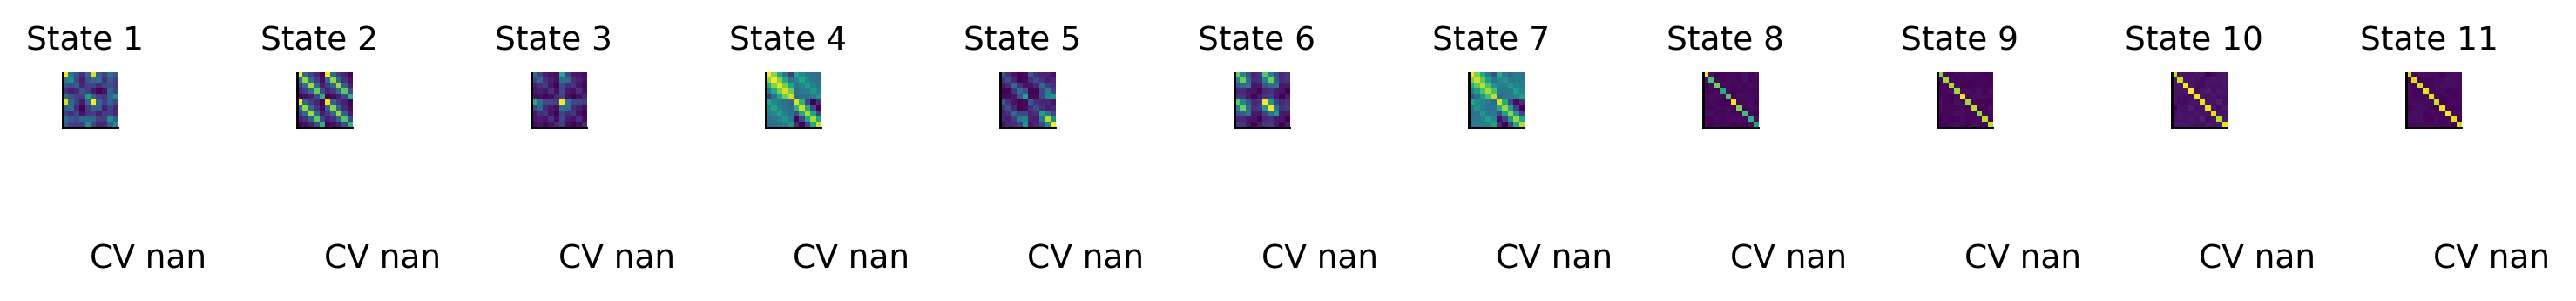

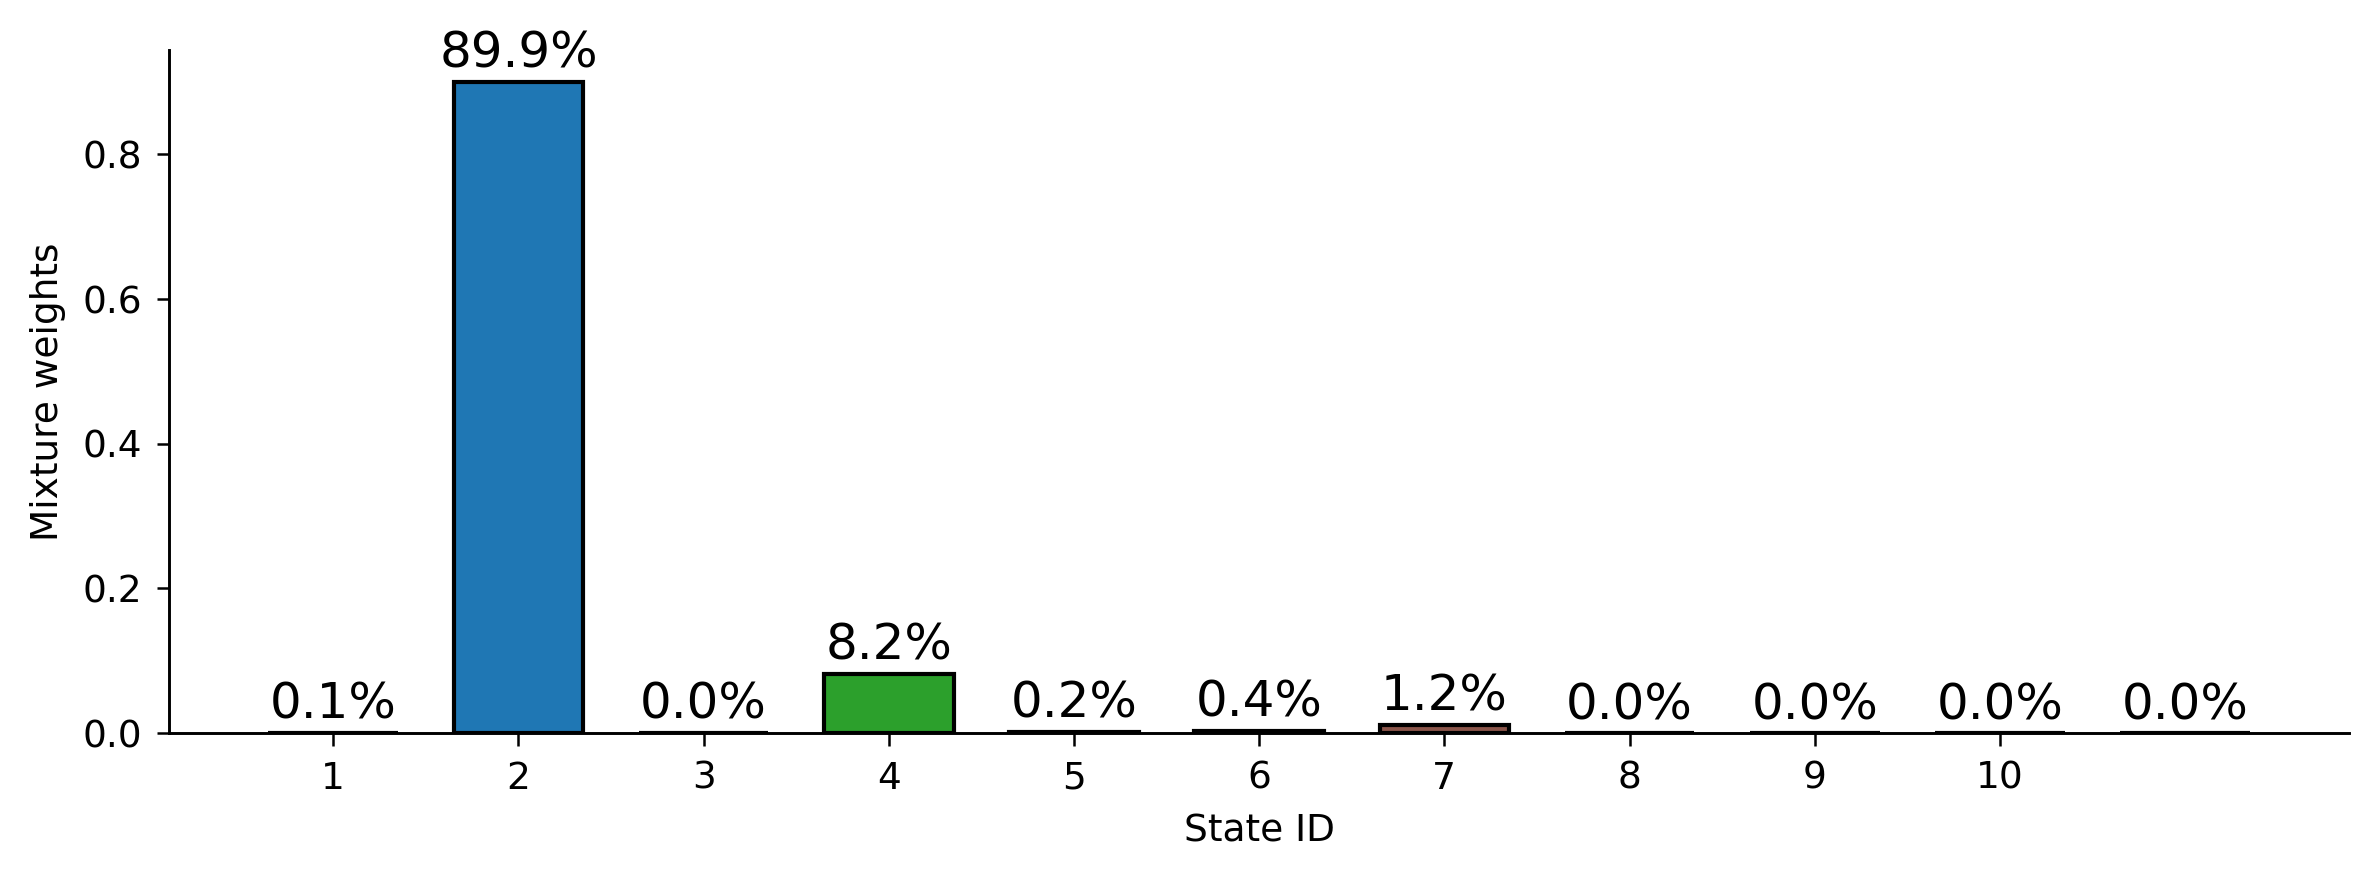

In [ ]:

import matplotlib.pyplot as plt

res = results[0,0,0,1,3]
est_params = res["est_params"]



from nds_toolbox.utils.helper import match_states
from nds_toolbox.analysis.utils import imputing_mode
from nds_toolbox.sim.bursts.simulator import simulate_bursty_signal
from nds_toolbox.preprocessing.features import (compute_tde,trim_data)
from nds_toolbox.preprocessing.features import choose_embedding_dim
from nds_toolbox.utils.helper import compare_decoding_performance
from nds_toolbox.models.dpgmm_numpyro import fit_DPGMM, truncate, get_states
from sklearn.metrics import matthews_corrcoef
import jax.numpy as jnp

num_emb = 5
num_embs = [3,5,7,9,11,13,15,17,19,21,23,25,27,29,31,33,35] 
use_different_emb = True

mccs = np.empty_like(results)

freqs = [15, 20, 25, 30, 35, 40]


est_params = res["est_params"]
alpha = est_params["alpha"]
weights = est_params["weights"]
means = est_params["means"]
covs = est_params["covs"]

states = states_samples[0,0,0,1,0]                
states2 = states_samples[0,0,0,1,4]

combined_states = np.empty_like(states)
state_dict = {'00': 0}
state_num = 1
for i, (s1, s2) in enumerate(zip(states, states2)):
    s =  str(s1) + str(s2)
    if s not in state_dict:
        state_dict[s] = state_num
        state_num += 1
    combined_states[i] = state_dict[s]


                 
trimmed_states = trim_data(combined_states, num_emb, verbose = False)




#generate tde
signal = signal_samples[0,0,0,1,0] 
signal2 = signal_samples[0,0,0,1,4] 

signal = (signal - np.mean(signal))/ np.std(signal)
signal2 = (signal2 - np.mean(signal2))/ np.std(signal2)


tde_signal = compute_tde(signal, num_emb)
tde_signal2 = compute_tde(signal2, num_emb)
tde_signal = np.concatenate([tde_signal, tde_signal2], axis=1)

                    
trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(means, covs, weights, verbose=True, return_info=True,edge_states_cv=0.4, num_channels=2)
num_effective_states = max(len(trunc_weights), state_num)
est_states_dpgmm = get_states(tde_signal, trunc_means, trunc_covs, trunc_weights)
est_states_dpgmm = imputing_mode(est_states_dpgmm, min_samples=3)
est_states_dpgmm_onehot = np.eye(num_effective_states)[est_states_dpgmm]
trimmed_states_onehot = np.eye(num_effective_states)[trimmed_states]

order, est_states_dpgmm_onehot = match_states(trimmed_states_onehot, est_states_dpgmm_onehot, verbose=False)
est_states_dpgmm = np.argmax(est_states_dpgmm_onehot, axis=1)

mcc_dpgmm = matthews_corrcoef(trimmed_states, est_states_dpgmm)
                    




























fig, ax = plt.subplots(1, est_params['covs'].shape[0], figsize=(10, 6), sharex=True, sharey=True)

for i, cov in enumerate(est_params['covs']):
    ax[i].imshow(cov, cmap="viridis")


    dim = cov.shape[0]

    cov_channel_1 = cov[0:21, 0:21]
    cov_channel_2 = cov[21:42, 21:42]

    diag_channel_1 = jnp.diagonal(cov_channel_1, axis1=-2, axis2=-1)
    mu_1 = jnp.mean(diag_channel_1, axis=-1)
    sd_1 = jnp.std(diag_channel_1, axis=-1)
    cv_diags_1 = sd_1 / (mu_1 + 1e-12)

    diag_channel_2 = jnp.diagonal(cov_channel_2, axis1=-2, axis2=-1)
    mu_2 = jnp.mean(diag_channel_2, axis=-1)
    sd_2 = jnp.std(diag_channel_2, axis=-1)
    cv_diags_2 = sd_2 / (mu_2 + 1e-12)


    cv_diags = (cv_diags_1 + cv_diags_2) / 2



    ax[i].set_title(f"State {i+1} ")
    ax[i].text(15, 35, f"CV {cv_diags :.3f}", ha='center')
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.show()

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(10)]
grey = ["#E0E0E0"]
colors = grey + colors

fig, ax = plt.subplots(1, 1, figsize=(8, 3))

for k, w in enumerate(est_params['weights']):
        ax.bar(
            k,
            w,
            width=0.7,
            color=colors[k],
            zorder=1,
            align="center",
            edgecolor="k",
        )
        ax.text(
            k,
            w + 0.02,
            f"{w * 100:.1f}%",
            ha="center",
            color="k",
            fontsize=12,
        )

ax.set_ylabel("Mixture weights")
ax.set_xlabel("State ID")
ax.set_xticks(np.arange(10), labels=np.arange(1, 10 + 1))
plt.show()







## Single Run Analysis after truncate

/home/gerrit/Bachelor/MC-TDE-DP-GMM/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


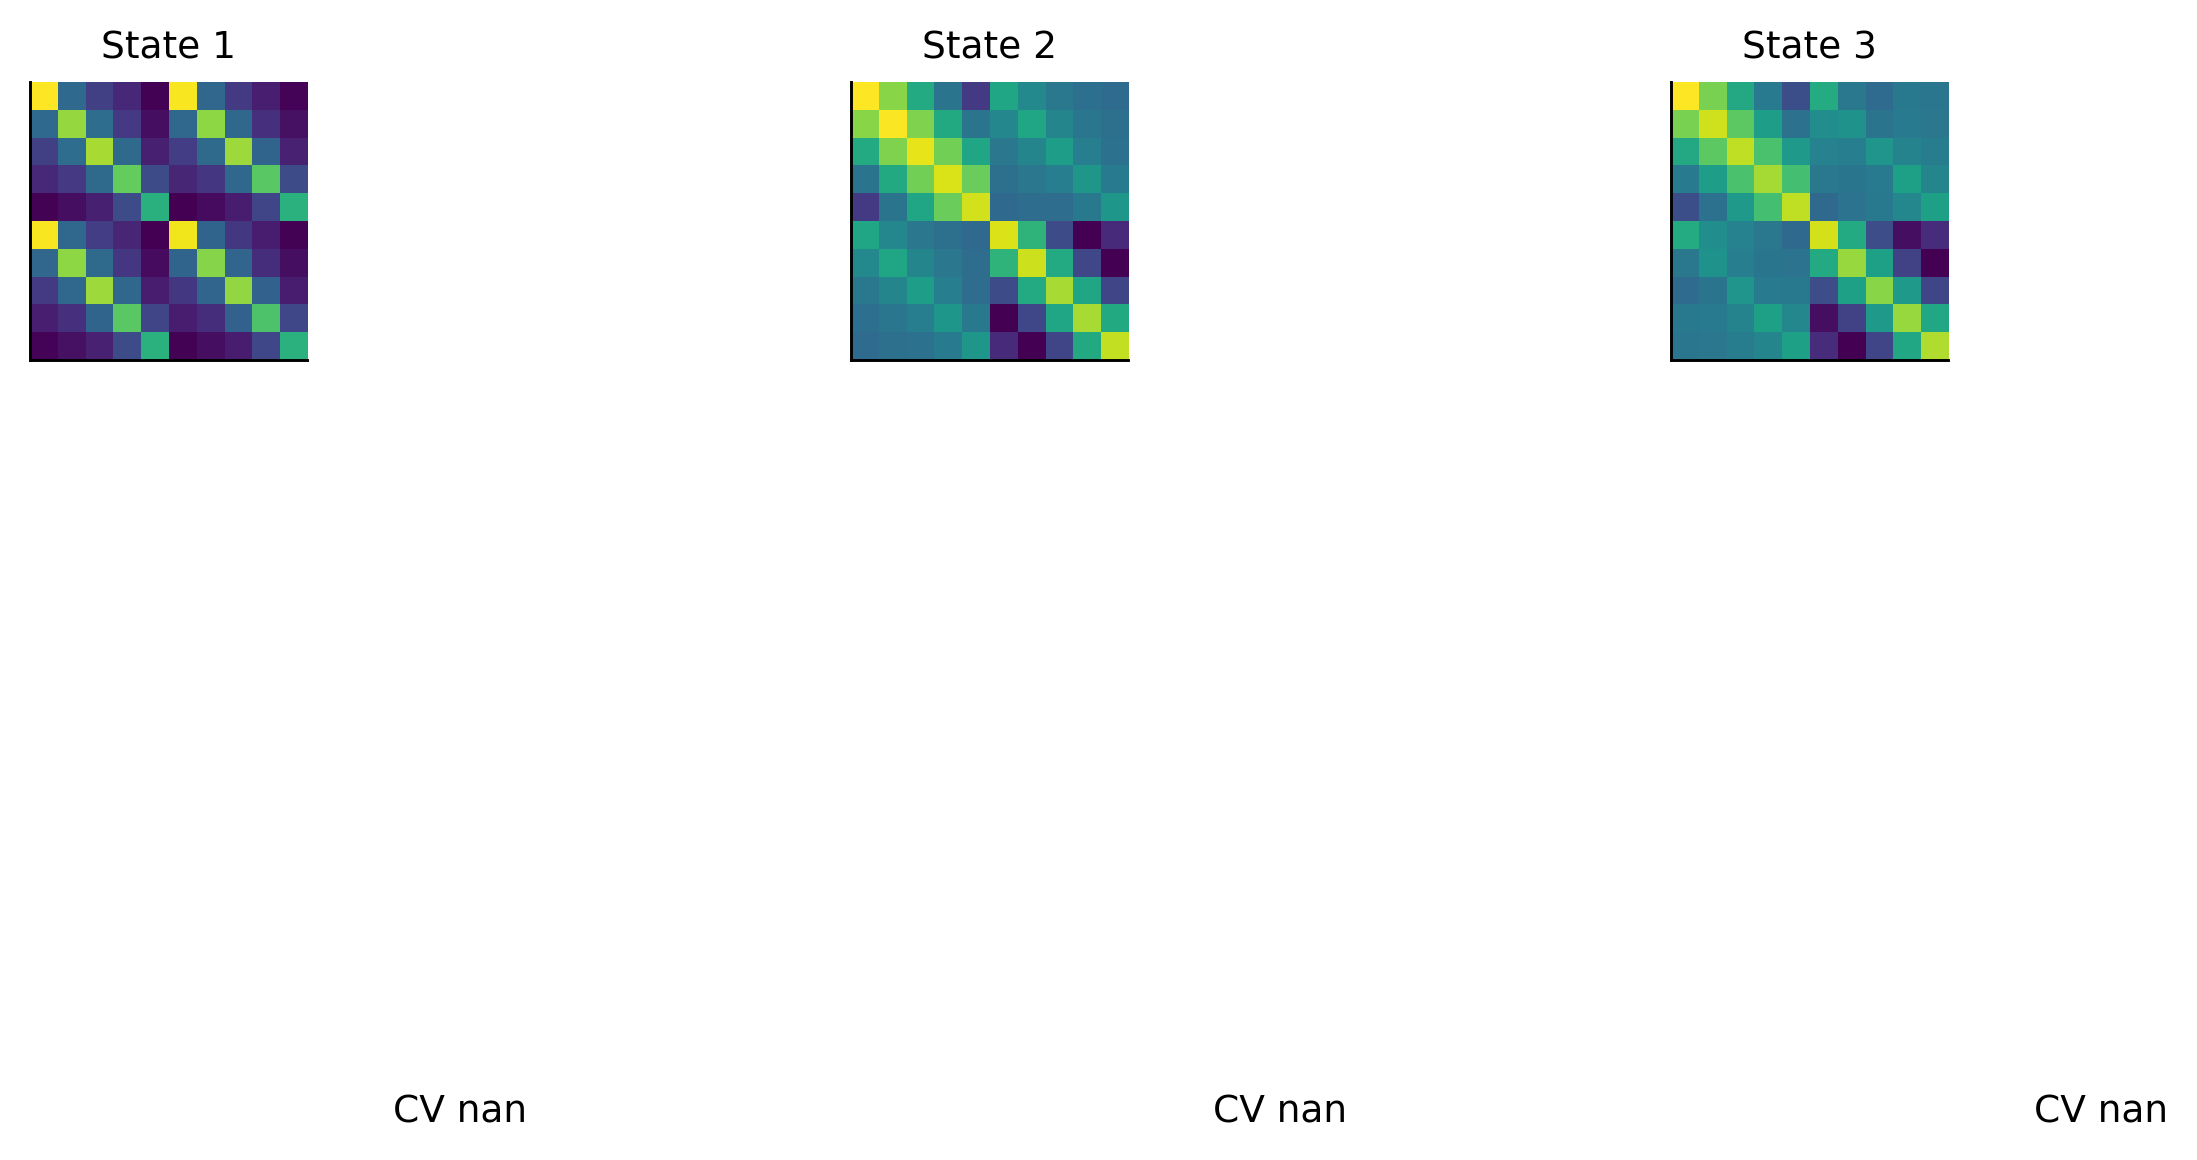

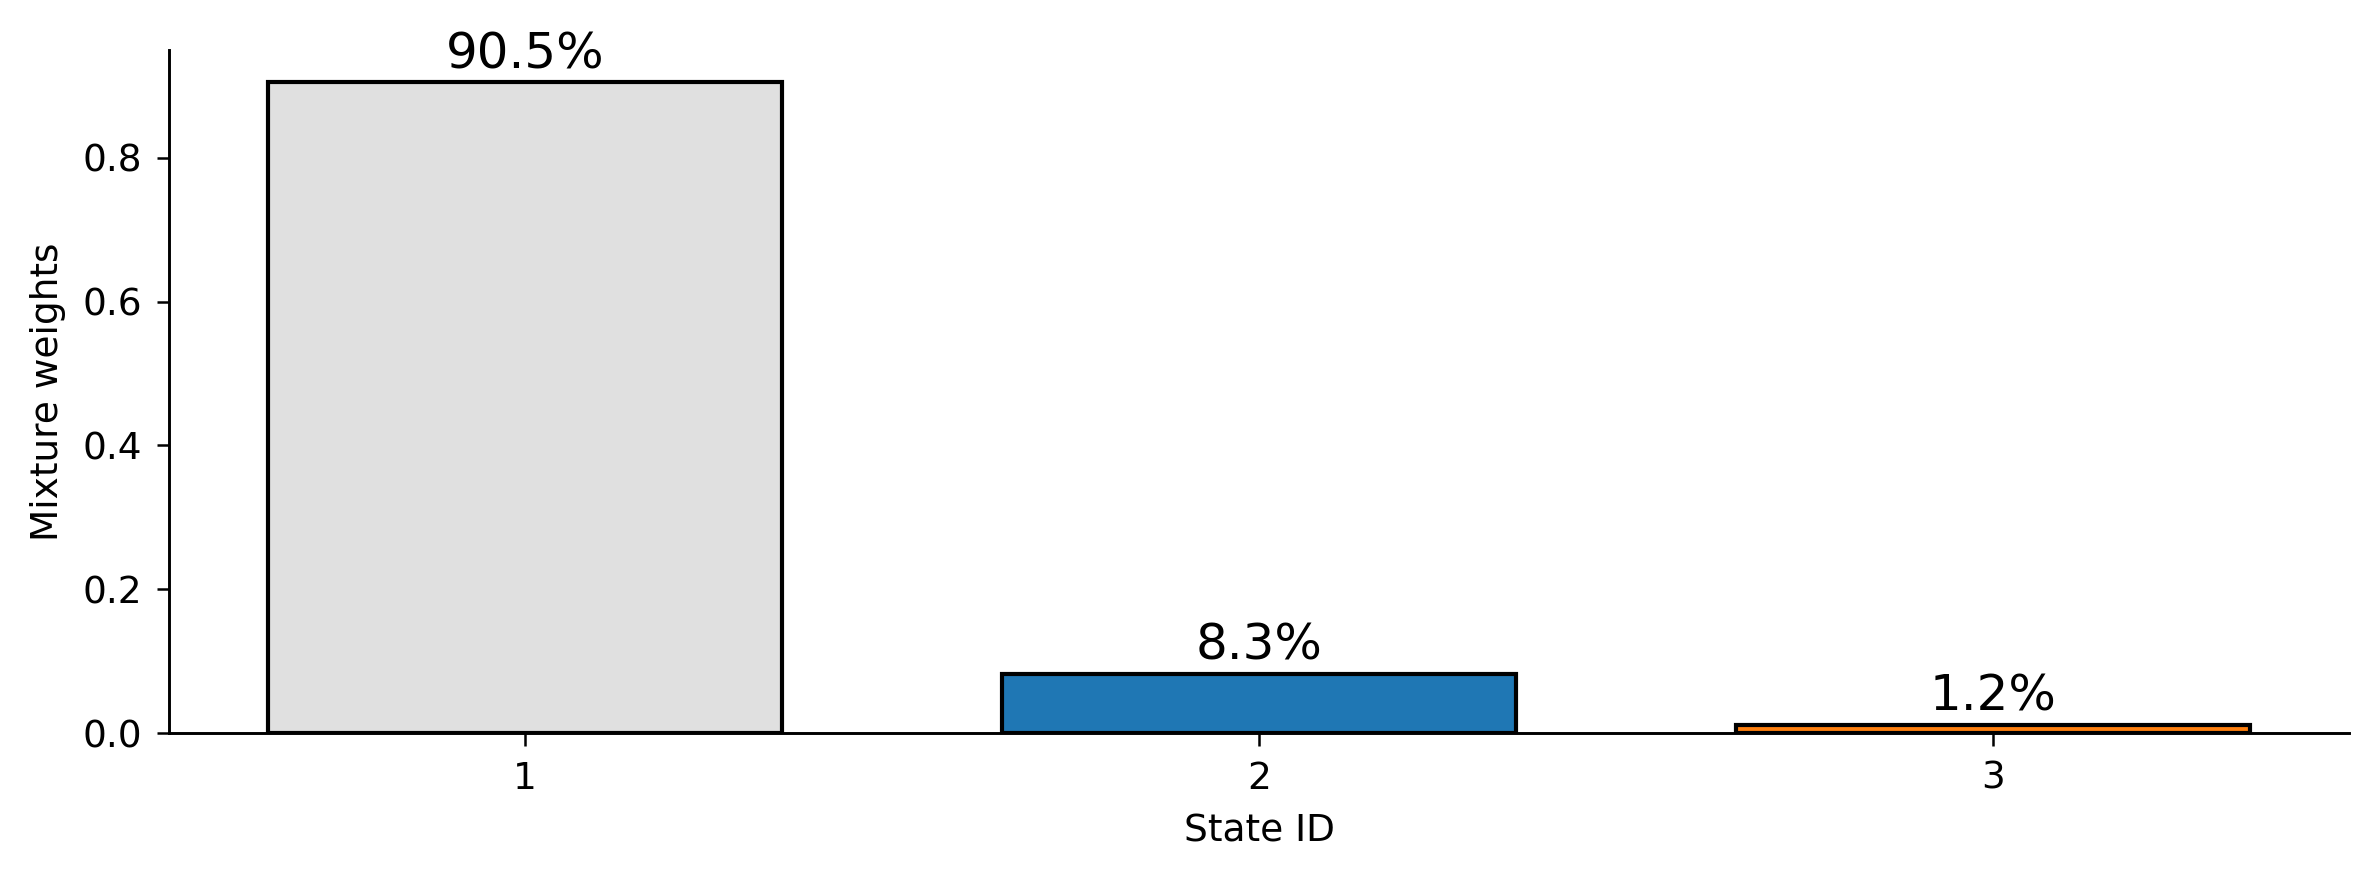

/home/gerrit/Bachelor/MC-TDE-DP-GMM/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


(3, 10, 10)


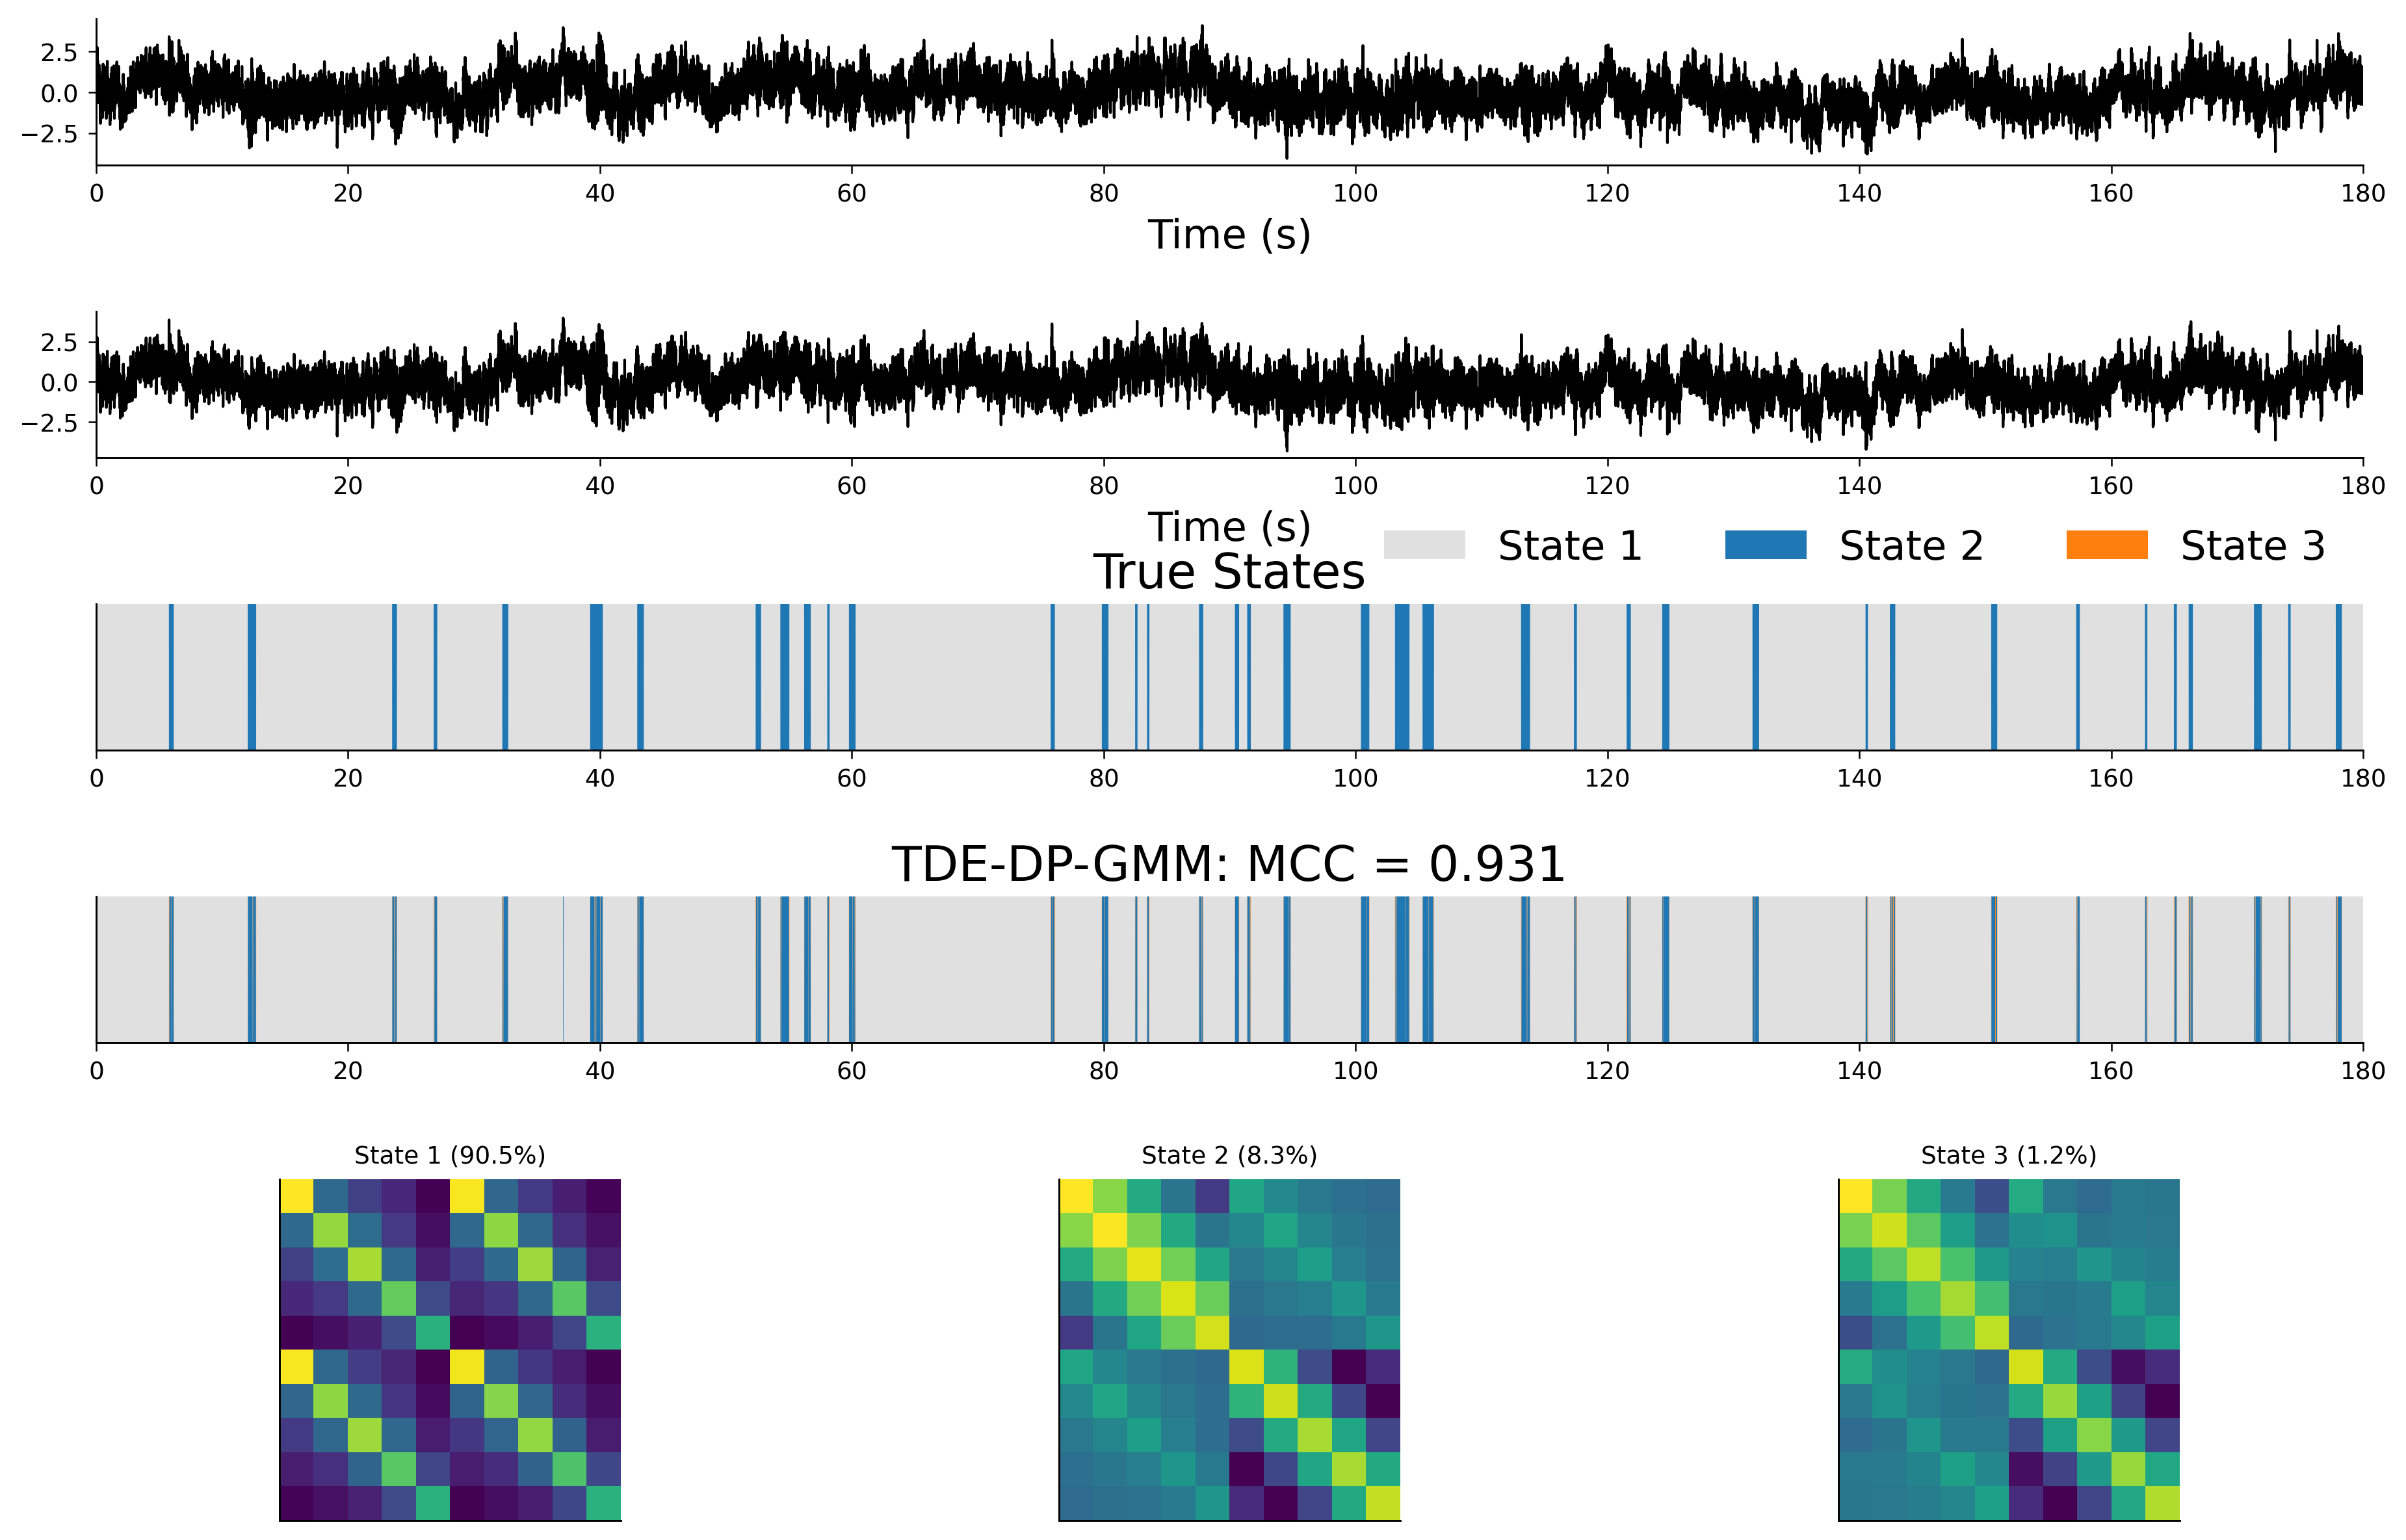

In [97]:

import matplotlib.pyplot as plt
from nds_toolbox.models.dpgmm_numpyro import fit_DPGMM, truncate, get_states

fs = 250



est_params = res["est_params"]
trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(est_params['means'], est_params['covs'], est_params['weights'], verbose=False, return_info=True,edge_states_cv=0.3, num_channels=2)
trimmed_time_vec = np.linspace(0, len(trimmed_states)/fs, len(trimmed_states))
trimmed_signal = trim_data(signal, num_emb, verbose = False)
trimmed_signal2 = trim_data(signal2, num_emb, verbose= False)
trimmed_states = trim_data(combined_states, num_emb, verbose = False)

num_effective_states = max(len(trunc_weights), state_num)
est_states_dpgmm = get_states(tde_signal, trunc_means, trunc_covs, trunc_weights)
est_states_dpgmm = imputing_mode(est_states_dpgmm, min_samples=3)
est_states_dpgmm_onehot = np.eye(num_effective_states)[est_states_dpgmm]
rimmed_states_onehot = np.eye(num_effective_states)[trimmed_states]

order, est_states_dpgmm_onehot = match_states(trimmed_states_onehot, est_states_dpgmm_onehot, verbose=False)
est_states_dpgmm = np.argmax(est_states_dpgmm_onehot, axis=1)

fig, ax = plt.subplots(1, trunc_covs.shape[0], figsize=(10, 6), sharex=True, sharey=True)
fig.set_figheight(1.2)

if trunc_covs.shape[0] == 1:
        ax.imshow(trunc_covs[0], cmap="viridis")
        ax.set_title(f"State {i+1}")
        diag = jnp.diagonal(trunc_covs[0], axis1=-2, axis2=-1)  # (k0, D)

        mu = jnp.mean(diag, axis=-1)
        sd = jnp.std(diag, axis=-1)
        cv_diags = sd / (mu + 1e-12)
        ax.text(15, 37, f"CV {cv_diags :.3f}", ha='center')
        ax.set_xticks([])
        ax.set_yticks([])
else:
    for i, cov in enumerate(trunc_covs):

        cov_channel_1 = cov[0:21, 0:21]
        cov_channel_2 = cov[21:42, 21:42]

        diag_channel_1 = jnp.diagonal(cov_channel_1, axis1=-2, axis2=-1)
        mu_1 = jnp.mean(diag_channel_1, axis=-1)
        sd_1 = jnp.std(diag_channel_1, axis=-1)
        cv_diags_1 = sd_1 / (mu_1 + 1e-12)

        diag_channel_2 = jnp.diagonal(cov_channel_2, axis1=-2, axis2=-1)
        mu_2 = jnp.mean(diag_channel_2, axis=-1)
        sd_2 = jnp.std(diag_channel_2, axis=-1)
        cv_diags_2 = sd_2 / (mu_2 + 1e-12)


        cv_diags = (cv_diags_1 + cv_diags_2) / 2
        
        ax[i].text(15, 37, f"CV {cv_diags :.3f}", ha='center')
        ax[i].imshow(cov, cmap="viridis")
        ax[i].set_title(f"State {i+1}")
        ax[i].set_xticks([])
        ax[i].set_yticks([])

plt.show()

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(10)]
grey = ["#E0E0E0"]
colors = grey + colors

fig, ax = plt.subplots(1, 1, figsize=(8, 3))

for k, w in enumerate(trunc_weights):
        ax.bar(
            k,
            w,
            width=0.7,
            color=colors[k],
            zorder=1,
            align="center",
            edgecolor="k",
        )
        ax.text(
            k,
            w + 0.02,
            f"{w * 100:.1f}%",
            ha="center",
            color="k",
            fontsize=12,
        )

ax.set_ylabel("Mixture weights")
ax.set_xlabel("State ID")
ax.set_xticks(np.arange(num_effective_states), labels=np.arange(1, num_effective_states + 1))
plt.show()










cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(10)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"State {i+1}" for i in range(10)]

# top row height larger than bottom row
fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(nrows=2, ncols=1, height_ratios=[3, 1], hspace=0.2)

# top: 3 stacked subplots (share x)
ax_top = fig.add_subplot(gs[0])
ax_top.set_xticklabels([])
ax_top.set_yticklabels([])
ax_top.set_yticks([])
ax_top.set_xticks([])
ax_top.axis('off')
# create a small inner GridSpec to host 3 rows sharing x inside the top region
gs_top = gridspec.GridSpecFromSubplotSpec(nrows=4, ncols=1, subplot_spec=gs[0], hspace=1)

ax0 = fig.add_subplot(gs_top[0])
ax3 = fig.add_subplot(gs_top[1], sharex=ax0)
ax1 = fig.add_subplot(gs_top[2], sharex=ax0)
ax2 = fig.add_subplot(gs_top[3], sharex=ax0)



# first subplot (signal)
ax0.plot(trimmed_time_vec, trimmed_signal, color="k")
ax0.set_xlabel("Time (s)", fontsize=15)
#ax0.set_title(heading + f"; learning rate: {lr}; epochs = {num_epochs}; embedding dim = {num_emb}", fontsize=18)
ax0.set_xlim(0, 60)


ax3.plot(trimmed_time_vec, trimmed_signal2, color="k")
ax3.set_xlabel("Time (s)", fontsize=15)
ax3.set_xlim(0, 180)





# second subplot (true states)
ax1.stackplot(trimmed_time_vec, trimmed_states_onehot.T, colors=colors, labels=state_labels, linewidth=0)
ax1.set_title("True States", fontsize=18)
ax1.set_ylim(0, 1)
ax1.set_yticks([])

# third subplot (estimated states)
ax2.stackplot(trimmed_time_vec, est_states_dpgmm_onehot.T, colors=colors, linewidth=0)
ax2.set_title(f"TDE-DP-GMM: MCC = {np.round(mcc_dpgmm, 3)}", fontsize=18)
ax2.set_ylim(0, 1)
ax2.set_yticks([])


ax1.legend(
    loc="lower right",
    bbox_to_anchor=(1.0, 1.0),
    ncol=10,
    frameon=False,
    fontsize=15,
)

# bottom row: covariance images
# determine number of cov axes horizontally
n_cov = trunc_covs.shape[0]
# create sub-gridspec for the bottom row with n_cov columns
gs_bottom = gridspec.GridSpecFromSubplotSpec(nrows=1, ncols=n_cov, subplot_spec=gs[1], wspace=0.1)

if n_cov == 1:
    ax_cov = fig.add_subplot(gs_bottom[0])
    ax_cov.imshow(trunc_covs[0], cmap="viridis")
    ax_cov.set_title("State 1 (" + str(trunc_weights[0]) + ")")
    ax_cov.set_xticks([])
    ax_cov.set_yticks([])
else:
    for i in range(n_cov):
        ax_cov = fig.add_subplot(gs_bottom[i])
        ax_cov.imshow(trunc_covs[i], cmap="viridis")
        ax_cov.set_title(f"State {i+1} ({trunc_weights[i] * 100:.1f}%)")
        ax_cov.set_xticks([])
        ax_cov.set_yticks([])

print(trunc_covs.shape)
plt.show()

## Results

(3, 1, 1, 17, 5)
(5, 17)
(3, 1, 1, 17, 5)


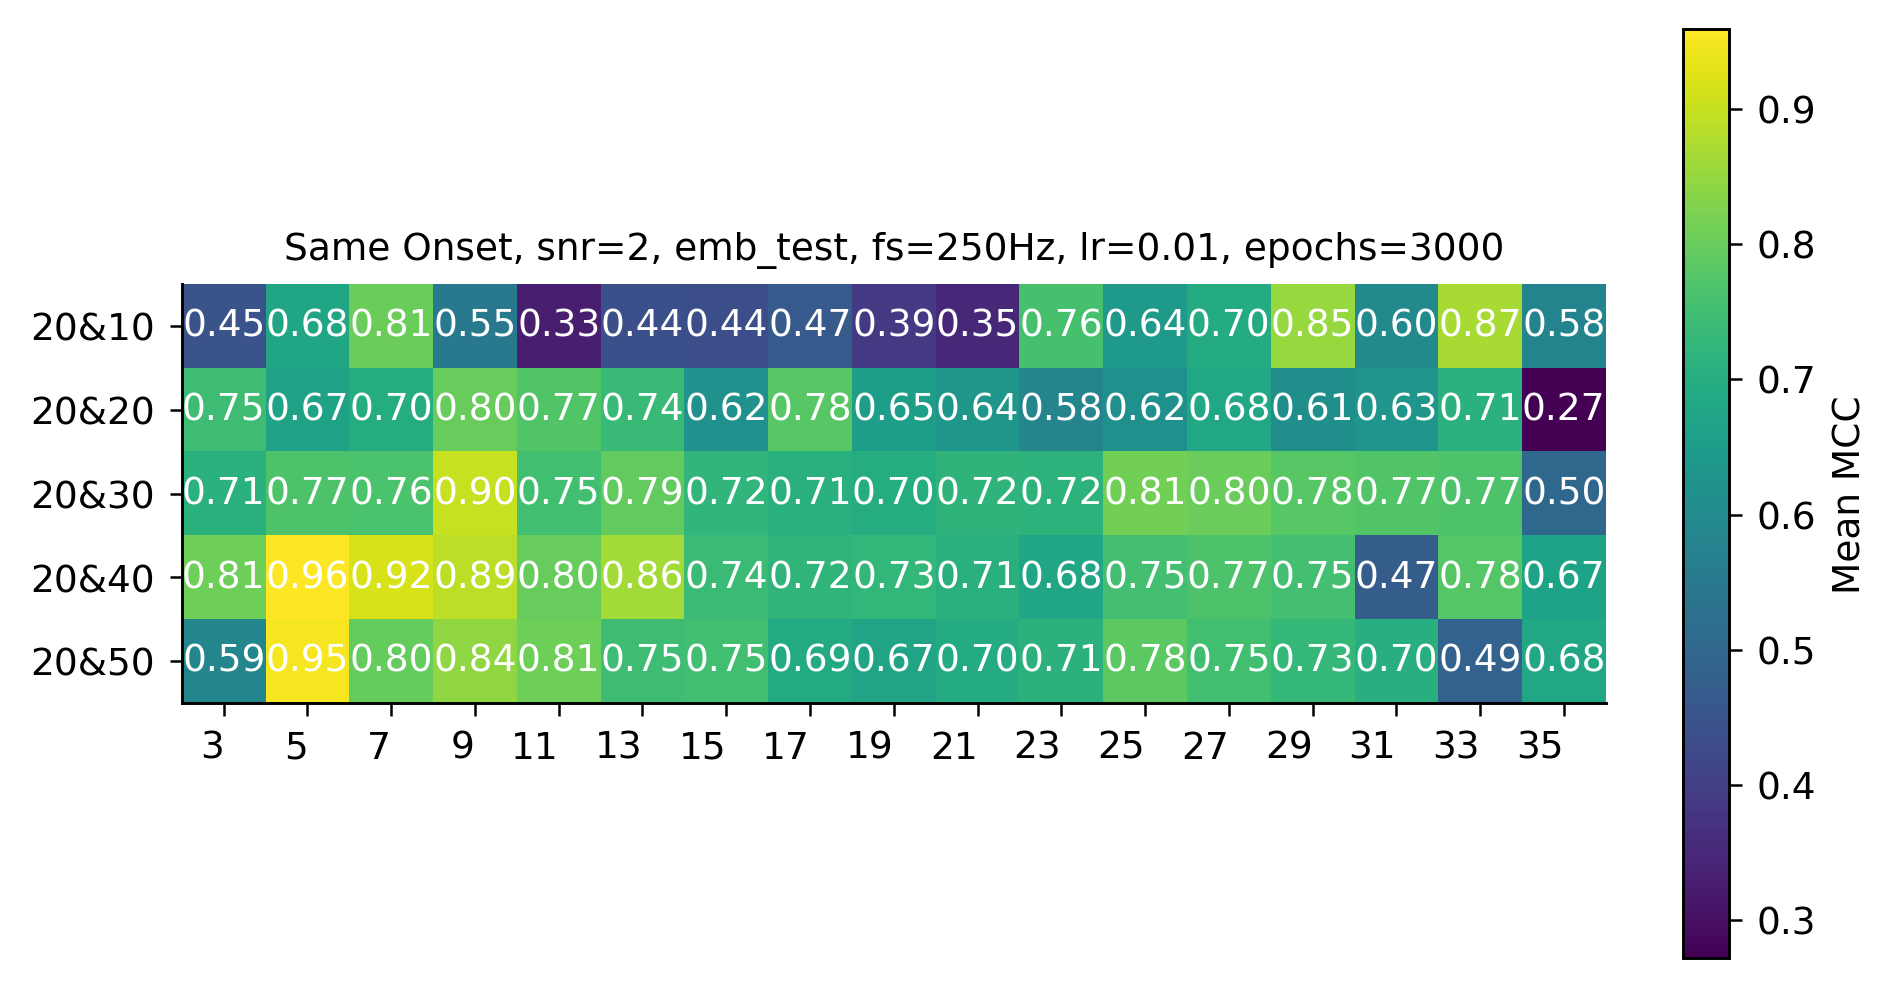

In [87]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import matplotlib.gridspec as gridspec

samples = len(results)
formatted_mccs = np.empty((len(results[0,0,0,0]), len(results[0,0,0])), dtype=float)

print(mccs.shape)

for snrs_id, snrs in enumerate(mccs[0,0,0]):
    for mcc_id, mcc in enumerate(snrs):
        summed_mcc = 0
        for i in range(samples):
            summed_mcc += mccs[i, 0, 0, snrs_id, mcc_id]
        formatted_mccs[mcc_id, snrs_id] = summed_mcc / samples
print(formatted_mccs.shape)

print(results.shape)

snrs = ["-10", "-8", "-6", "-4","-2","0", "2", "4", "6", "8", "10"]
snrs = ["3", "5", "7", "9", "11", "13", "15", "17", "19", "21", "23", "25", "27", "29", "31", "33", "35"]
sigs = ["20&5", "20&10", "20&15", "20&25", "20&30", "20&35"]
#sigs = ["40&10", "40&15", "40&20", "40&25", "40&30", "40&35"]
sigs = ["20&10", "20&20", "20&30", "20&40", "20&50"]
valfmt = matplotlib.ticker.StrMethodFormatter("{x:.2f}")
fig, ax = plt.subplots()
im = ax.imshow(formatted_mccs, cmap="viridis")
ax.set_title("Same Onset, snr=2, emb_test, fs=250Hz, lr=0.01, epochs=3000")

# Show all ticks and label them with the respective list entries
ax.set_xticks(range(len(snrs)), labels=snrs,
               ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(sigs)), labels=sigs)
cb = ax.figure.colorbar(im, ax=ax, fraction=0.03)
cb.ax.set_ylabel("Mean MCC")

# Loop over data dimensions and create text annotations.
for i in range(len(sigs)):
    for j in range(len(snrs)):
        text = ax.text(j, i, valfmt(formatted_mccs[i, j]),
                       ha="center", va="center", color="w")


fig.tight_layout()
plt.show()

#plt.show()
